# HITO 3 - Modelado, Entrenamiento y Validacion
## Asignatura: Desarrollo e Integracion de Servicios de IA (DISIA)
### Proyecto: Deteccion de Intrusos en Sistemas IIoT (X-IIoTID)

En este cuaderno se desarrolla la fase de **modelado, entrenamiento y validacion** a partir del conjunto final de variables obtenido en el Hito 2. A diferencia de la version provisional inicial, aqui **los modelos se entrenan realmente dentro del notebook** y el problema principal se formula como una **clasificación directa del tipo de trafico (`class1`)**, incluyendo `normal` como una clase mas.

A partir de la prediccion del tipo, se derivan despues:

1. La **categoria** (`class2`), mediante la taxonomia de ataques.
2. La **clasificacion binaria** (`class3`), distinguiendo `normal` frente a `attack`.

Este planteamiento permite que toda la fase de modelado sea trazable y quede autocontenida dentro del propio notebook.

### Objetivos del Hito 3
1. Cargar las matrices finales del Hito 2 y reconstruir las etiquetas si no estuviesen guardadas.
2. Definir el protocolo correcto de clasificación directa por tipo.
3. Entrenar varias familias de modelos representativas dentro del notebook.
4. Comparar su rendimiento en validacion y en test a nivel de tipo, categoria y binaria.
5. Analizar los mejores modelos y justificar la seleccion final.
6. Exportar tablas, predicciones, modelos y figuras a una carpeta de resultados propia.

### Modelos incluidos
- `DecisionTree`: referencia interpretable basada en arboles.
- `RandomForest`: modelo de ensamble para datos tabulares, candidato principal.
- `LogisticRegression`: baseline lineal multiclase.
- `GaussianNB`: baseline probabilistico simple.
- `MLP`: red neuronal multicapa como familia neuronal del estudio.

---
### Indice del notebook
1. [Carga de datos y reconstrucción de etiquetas](#1)
2. [Definicion del problema y taxonomia](#2)
3. [Configuracion experimental y modelos](#3)
4. [Entrenamiento de modelos](#4)
5. [Resultados en validacion](#5)
6. [Resultados finales en test](#6)
7. [Analisis detallado de los mejores modelos](#7)
8. [Conclusiones del modelado](#8)


In [1]:
from pathlib import Path
import gc
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', palette='muted')
pd.options.display.float_format = lambda x: f"{x:.4f}"


### 1. Carga de datos y reconstrucción de etiquetas <a name="1"></a>

El Hito 2 ya dejó preparadas las matrices `X_train_final`, `X_val_final` y `X_test_final` con **34 variables**. Para poder entrenar de forma trazable en este Hito 3 necesitamos además las etiquetas `y_*` alineadas con esas particiones.

Como el particionado del Hito 2 es determinista (`70/15/15`, `random_state=42`, estratificado por `class3`), es posible **reconstruir las etiquetas** a partir del dataset raw si todavía no existen en `DATA`.

Las salidas generadas por este notebook se guardarán en una carpeta nueva, separada de los artefactos provisionales antiguos, para evitar mezclar resultados heredados con resultados entrenados realmente en este proyecto.


In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'DATA'
RAW_PATH = ROOT / 'datos' / 'raw' / 'X-IIoTID dataset.csv'
RESULTS_DIR = ROOT / 'RESULTADOS_HITO3'
MODELS_DIR = RESULTS_DIR / 'modelos'
PREDICTIONS_DIR = RESULTS_DIR / 'predicciones'
TABLES_DIR = RESULTS_DIR / 'tablas'
FIGURES_DIR = RESULTS_DIR / 'figuras'

for directory in [RESULTS_DIR, MODELS_DIR, PREDICTIONS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def ensure_labels_from_raw(raw_path: Path, data_dir: Path) -> bool:
    required = [
        data_dir / 'y_train_class1.csv', data_dir / 'y_val_class1.csv', data_dir / 'y_test_class1.csv',
        data_dir / 'y_train_class2.csv', data_dir / 'y_val_class2.csv', data_dir / 'y_test_class2.csv',
        data_dir / 'y_train_class3.csv', data_dir / 'y_val_class3.csv', data_dir / 'y_test_class3.csv',
    ]

    if all(path.exists() for path in required):
        return False

    if not raw_path.exists():
        raise FileNotFoundError(
            f'No se ha encontrado el dataset raw en {raw_path}. Copia ah? el CSV original para reconstruir las etiquetas.'
        )

    common_replacements = {'-': pd.NA, '?': pd.NA, 'nan': pd.NA, 'NaN': pd.NA}
    df = pd.read_csv(raw_path, low_memory=False)

    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.lower().replace(common_replacements)

    y = df[['class1', 'class2', 'class3']].copy()
    X = df.drop(columns=['class1', 'class2', 'class3'], errors='ignore')

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y['class3']
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=(0.15 / 0.85), random_state=42, stratify=y_temp['class3']
    )

    for obj in [X_train, X_val, X_test, y_train, y_val, y_test]:
        obj.reset_index(drop=True, inplace=True)

    for split_name, y_split in [('train', y_train), ('val', y_val), ('test', y_test)]:
        for cls in ['class1', 'class2', 'class3']:
            y_split[[cls]].to_csv(data_dir / f'y_{split_name}_{cls}.csv', index=False)

    return True


generated_labels = ensure_labels_from_raw(RAW_PATH, DATA_DIR)

X_train = pd.read_csv(DATA_DIR / 'X_train_final.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val_final.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_final.csv')

y_train_type = pd.read_csv(DATA_DIR / 'y_train_class1.csv')['class1']
y_val_type = pd.read_csv(DATA_DIR / 'y_val_class1.csv')['class1']
y_test_type = pd.read_csv(DATA_DIR / 'y_test_class1.csv')['class1']

y_train_cat = pd.read_csv(DATA_DIR / 'y_train_class2.csv')['class2']
y_val_cat = pd.read_csv(DATA_DIR / 'y_val_class2.csv')['class2']
y_test_cat = pd.read_csv(DATA_DIR / 'y_test_class2.csv')['class2']

y_train_bin = pd.read_csv(DATA_DIR / 'y_train_class3.csv')['class3']
y_val_bin = pd.read_csv(DATA_DIR / 'y_val_class3.csv')['class3']
y_test_bin = pd.read_csv(DATA_DIR / 'y_test_class3.csv')['class3']

summary_df = pd.DataFrame(
    {
        'conjunto': ['train', 'val', 'test'],
        'filas_X': [len(X_train), len(X_val), len(X_test)],
        'filas_y': [len(y_train_type), len(y_val_type), len(y_test_type)],
        'columnas_X': [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    }
)

display(summary_df)
print('Etiquetas reconstruidas desde raw:', generated_labels)
print('Directorio de resultados:', RESULTS_DIR)

summary_df.to_csv(TABLES_DIR / 'resumen_particiones.csv', index=False)


,conjunto,filas_X,filas_y,columnas_X
0,train,574583,574583,34
1,val,123125,123125,34
2,test,123126,123126,34


Etiquetas reconstruidas desde raw: False
Directorio de resultados: C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\RESULTADOS_HITO3


### 2. Definicion del problema y taxonomia <a name="2"></a>

En esta version final del Hito 3, el objetivo principal del entrenamiento es `class1`, es decir, el **tipo exacto de trafico**. Esto implica que el modelo debe distinguir directamente entre `normal` y los distintos tipos de ataque.

A partir de `class1` se puede reconstruir automaticamente:

1. `class2`: categoria de ataque.
2. `class3`: decision binaria `normal` / `attack`.

Esta formulacion es metodologicamente mas limpia para el proyecto, porque evita entrenar arquitecturas jerarquicas heredadas y centra el modelado en la salida final realmente relevante.


In [3]:
mapping_df = pd.DataFrame(
    {
        'class1': pd.concat([y_train_type, y_val_type, y_test_type], ignore_index=True),
        'class2': pd.concat([y_train_cat, y_val_cat, y_test_cat], ignore_index=True),
        'class3': pd.concat([y_train_bin, y_val_bin, y_test_bin], ignore_index=True),
    }
).drop_duplicates(subset='class1').sort_values('class1').reset_index(drop=True)

type_to_category = mapping_df.set_index('class1')['class2'].to_dict()
type_to_binary = mapping_df.set_index('class1')['class3'].to_dict()

class_inventory = mapping_df.copy()
class_inventory['soporte_train'] = class_inventory['class1'].map(y_train_type.value_counts())
class_inventory = class_inventory.sort_values('soporte_train', ascending=False).reset_index(drop=True)

display(class_inventory)
print('Numero de clases en class1:', class_inventory['class1'].nunique())
print('Interpretacion: 1 clase normal +', class_inventory['class1'].nunique() - 1, 'tipos de ataque.')

class_inventory.to_csv(TABLES_DIR / 'inventario_clases.csv', index=False)


,class1,class2,class3,soporte_train
0,normal,normal,normal,294991
1,rdos,rdos,attack,98744
2,scanning_vulnerability,reconnaissance,attack,37029
3,generic_scanning,reconnaissance,attack,35141
4,bruteforce,weaponization,attack,33249
5,mqtt_cloud_broker_subscription,lateral _movement,attack,16511
6,discovering_resources,reconnaissance,attack,16253
7,exfiltration,exfiltration,attack,15565
8,insider_malcious,weaponization,attack,12123
9,modbus_register_reading,lateral _movement,attack,4126


Numero de clases en class1: 19
Interpretacion: 1 clase normal + 18 tipos de ataque.


### 3. Configuracion experimental y modelos <a name="3"></a>

Todos los modelos se entrenan sobre las mismas entradas:

- `X_train_final`, `X_val_final`, `X_test_final`
- conjunto de **34 variables** fijado en el Hito 2
- objetivo principal: `class1`
- evaluacion derivada sobre `class2` y `class3`

Se comparan varias familias de modelos para cubrir sesgos inductivos distintos y disponer de baselines claros. La idea no es optimizar exhaustivamente hiperparametros, sino obtener una comparativa honesta y reproducible entre familias representativas.


In [4]:
model_catalog = pd.DataFrame(
    [
        ['DecisionTree', 'Arbol de decision', 'Modelo interpretable, rapido y adecuado para datos tabulares.', "class_weight='balanced', max_depth=25, min_samples_leaf=5"],
        ['RandomForest', 'Bosque aleatorio', 'Ensamble de arboles, robusto y fuerte candidato principal.', "n_estimators=80, class_weight='balanced_subsample', min_samples_leaf=2"],
        ['LogisticRegression', 'Regresion logistica', 'Baseline lineal multiclase para medir no linealidad del problema.', "solver='saga', class_weight='balanced', max_iter=120"],
        ['GaussianNB', 'Naive Bayes gaussiano', 'Baseline probabilistico simple y muy rapido.', 'Configuracion por defecto'],
        ['MLP', 'Red neuronal multicapa', 'Familia neuronal del estudio, entrenada sobre las 34 variables finales.', "hidden_layer_sizes=(128, 64, 32), early_stopping=True, max_iter=20"],
    ],
    columns=['modelo', 'familia', 'motivo', 'configuracion_principal'],
)

display(model_catalog)
model_catalog.to_csv(TABLES_DIR / 'catalogo_modelos.csv', index=False)

models = {
    'DecisionTree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=25,
        min_samples_leaf=5,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=80,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=1,
        min_samples_leaf=2,
    ),
    'LogisticRegression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=120,
        solver='saga',
        n_jobs=1,
    ),
    'GaussianNB': GaussianNB(),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        random_state=42,
        max_iter=20,
        early_stopping=True,
        validation_fraction=0.1,
        batch_size=2048,
        learning_rate_init=1e-3,
        verbose=False,
    ),
}


,modelo,familia,motivo,configuracion_principal
0,DecisionTree,Arbol de decision,"Modelo interpretable, rapido y adecuado para d...","class_weight='balanced', max_depth=25, min_sam..."
1,RandomForest,Bosque aleatorio,"Ensamble de arboles, robusto y fuerte candidat...","n_estimators=80, class_weight='balanced_subsam..."
2,LogisticRegression,Regresion logistica,Baseline lineal multiclase para medir no linea...,"solver='saga', class_weight='balanced', max_it..."
3,GaussianNB,Naive Bayes gaussiano,Baseline probabilistico simple y muy rapido.,Configuracion por defecto
4,MLP,Red neuronal multicapa,"Familia neuronal del estudio, entrenada sobre ...","hidden_layer_sizes=(128, 64, 32), early_stoppi..."


### 4. Entrenamiento de modelos <a name="4"></a>

A continuacion se entrenan todos los modelos dentro del notebook. Para cada uno se guardan:

1. El modelo entrenado.
2. Las predicciones de validacion y test.
3. Las metricas derivadas en los tres niveles del problema.

La variable de seleccion principal es el **F1 macro sobre `class1`**, porque el problema presenta un desbalanceo fuerte entre tipos de ataque.


In [5]:
def evaluate_type_predictions(y_true_type, y_true_cat, y_true_bin, y_pred_type):
    y_pred_type = pd.Series(y_pred_type)
    y_pred_cat = y_pred_type.map(type_to_category)
    y_pred_bin = y_pred_type.map(type_to_binary)

    return {
        'acc_type': accuracy_score(y_true_type, y_pred_type),
        'prec_type': precision_score(y_true_type, y_pred_type, average='macro', zero_division=0),
        'rec_type': recall_score(y_true_type, y_pred_type, average='macro', zero_division=0),
        'f1_type': f1_score(y_true_type, y_pred_type, average='macro', zero_division=0),
        'acc_cat': accuracy_score(y_true_cat, y_pred_cat),
        'prec_cat': precision_score(y_true_cat, y_pred_cat, average='macro', zero_division=0),
        'rec_cat': recall_score(y_true_cat, y_pred_cat, average='macro', zero_division=0),
        'f1_cat': f1_score(y_true_cat, y_pred_cat, average='macro', zero_division=0),
        'acc_bin': accuracy_score(y_true_bin, y_pred_bin),
        'prec_bin': precision_score(y_true_bin, y_pred_bin, average='binary', pos_label='attack', zero_division=0),
        'rec_bin': recall_score(y_true_bin, y_pred_bin, average='binary', pos_label='attack', zero_division=0),
        'f1_bin': f1_score(y_true_bin, y_pred_bin, average='binary', pos_label='attack', zero_division=0),
    }


def classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(report).T


training_rows = []
val_predictions = {}
test_predictions = {}
reports_test = {}

for model_name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train_type)
    fit_seconds = time.time() - start

    val_pred = pd.Series(model.predict(X_val), name='pred_class1')
    test_pred = pd.Series(model.predict(X_test), name='pred_class1')

    val_predictions[model_name] = val_pred
    test_predictions[model_name] = test_pred
    reports_test[model_name] = classification_report_df(y_test_type, test_pred)

    joblib.dump(model, MODELS_DIR / f'{model_name}.joblib')
    val_pred.to_csv(PREDICTIONS_DIR / f'{model_name}_val.csv', index=False)
    test_pred.to_csv(PREDICTIONS_DIR / f'{model_name}_test.csv', index=False)
    reports_test[model_name].to_csv(TABLES_DIR / f'reporte_test_tipo_{model_name}.csv')

    val_metrics = evaluate_type_predictions(y_val_type, y_val_cat, y_val_bin, val_pred)
    test_metrics = evaluate_type_predictions(y_test_type, y_test_cat, y_test_bin, test_pred)

    row = {'modelo': model_name, 'tiempo_entrenamiento_s': round(fit_seconds, 2)}
    for metric_name, value in val_metrics.items():
        row[f'val_{metric_name}'] = value
    for metric_name, value in test_metrics.items():
        row[f'test_{metric_name}'] = value

    row['val_f1_mean'] = np.mean([row['val_f1_bin'], row['val_f1_cat'], row['val_f1_type']])
    row['test_f1_mean'] = np.mean([row['test_f1_bin'], row['test_f1_cat'], row['test_f1_type']])
    training_rows.append(row)

    gc.collect()

metrics_df = pd.DataFrame(training_rows).sort_values(['test_f1_mean', 'test_f1_type'], ascending=False).reset_index(drop=True)
display(metrics_df[['modelo', 'tiempo_entrenamiento_s', 'val_f1_bin', 'val_f1_cat', 'val_f1_type', 'val_f1_mean', 'test_f1_bin', 'test_f1_cat', 'test_f1_type', 'test_f1_mean']])

metrics_df.to_csv(TABLES_DIR / 'metricas_modelos.csv', index=False)


,modelo,tiempo_entrenamiento_s,val_f1_bin,val_f1_cat,val_f1_type,val_f1_mean,test_f1_bin,test_f1_cat,test_f1_type,test_f1_mean
0,RandomForest,112.4200,0.9957,0.9766,0.9452,0.9725,0.9960,0.9788,0.9559,0.9769
1,DecisionTree,14.0400,0.9853,0.9497,0.9024,0.9458,0.9862,0.9574,0.9143,0.9526
2,MLP,46.7900,0.9862,0.9487,0.9066,0.9472,0.9867,0.9523,0.9168,0.9519
3,GaussianNB,1.0100,0.6875,0.5431,0.5598,0.5968,0.6864,0.5410,0.5634,0.5969
4,LogisticRegression,219.3900,0.7135,0.5222,0.4825,0.5727,0.7133,0.5149,0.4809,0.5697


### 5. Resultados en validacion <a name="5"></a>

La validacion se utiliza para comprobar la consistencia relativa entre familias antes de mirar el conjunto de prueba. Se comparan tanto los tres F1 parciales como una media simple de F1 para tener una vision sintetica del rendimiento global.


,modelo,val_f1_bin,val_f1_cat,val_f1_type,val_f1_mean
0,RandomForest,0.9957,0.9766,0.9452,0.9725
1,DecisionTree,0.9853,0.9497,0.9024,0.9458
2,MLP,0.9862,0.9487,0.9066,0.9472
3,GaussianNB,0.6875,0.5431,0.5598,0.5968
4,LogisticRegression,0.7135,0.5222,0.4825,0.5727


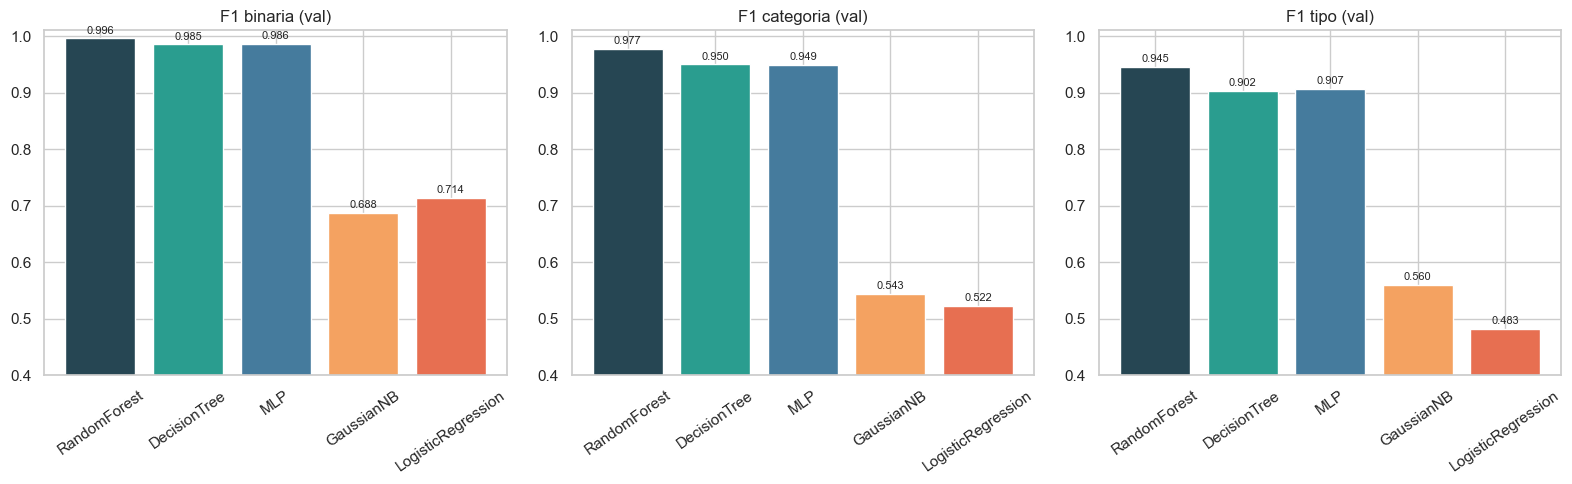

In [6]:
validation_ranking = metrics_df[['modelo', 'val_f1_bin', 'val_f1_cat', 'val_f1_type', 'val_f1_mean']].copy()
display(validation_ranking)

validation_ranking.to_csv(TABLES_DIR / 'ranking_validacion.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_map = [('val_f1_bin', 'F1 binaria (val)'), ('val_f1_cat', 'F1 categoria (val)'), ('val_f1_type', 'F1 tipo (val)')]
colors = ['#264653', '#2a9d8f', '#457b9d', '#f4a261', '#e76f51']

for ax, (col, title) in zip(axes, metric_map):
    ax.bar(metrics_df['modelo'], metrics_df[col], color=colors)
    ax.set_title(title)
    ax.set_ylim(0.40, 1.01)
    ax.tick_params(axis='x', rotation=35)
    for idx, value in enumerate(metrics_df[col]):
        ax.text(idx, value + 0.005, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'f1_validacion.png', dpi=220, bbox_inches='tight')
plt.show()


### 6. Resultados finales en test <a name="6"></a>

Una vez entrenados y validados los modelos, se comparan en el conjunto de prueba. Esta es la tabla principal para la memoria, ya que resume el comportamiento real de cada familia sobre datos no vistos.


,modelo,tiempo_entrenamiento_s,test_f1_bin,test_f1_cat,test_f1_type,test_f1_mean
0,RandomForest,112.4200,0.9960,0.9788,0.9559,0.9769
1,DecisionTree,14.0400,0.9862,0.9574,0.9143,0.9526
2,MLP,46.7900,0.9867,0.9523,0.9168,0.9519
3,GaussianNB,1.0100,0.6864,0.5410,0.5634,0.5969
4,LogisticRegression,219.3900,0.7133,0.5149,0.4809,0.5697


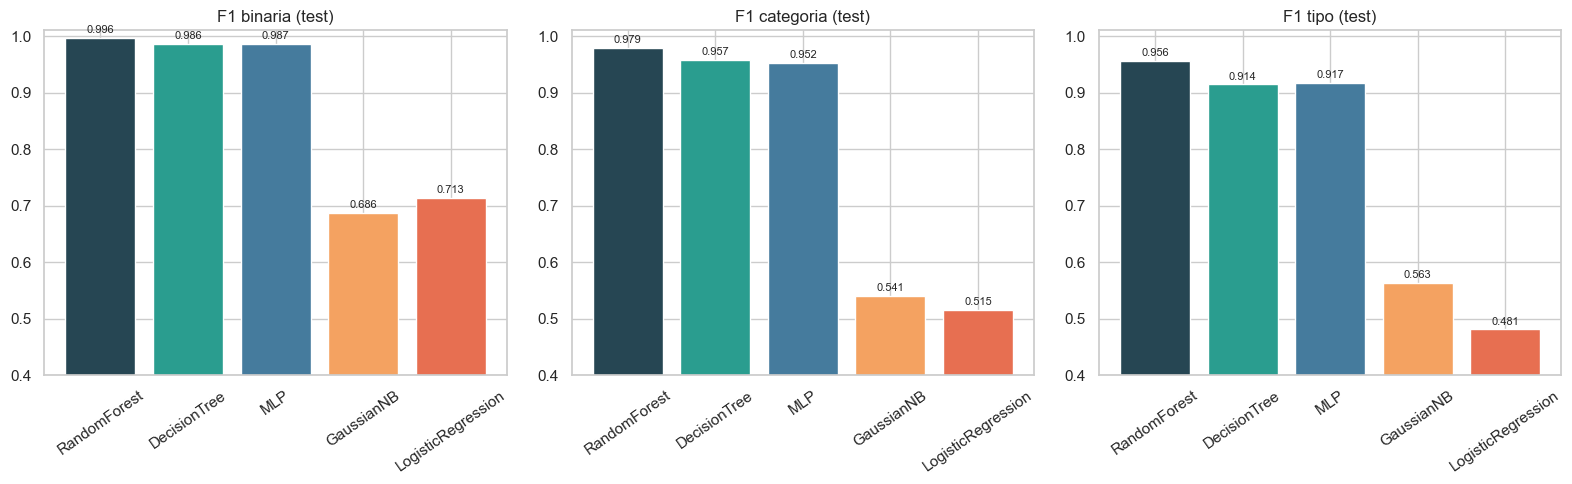

In [7]:
test_ranking = metrics_df[['modelo', 'tiempo_entrenamiento_s', 'test_f1_bin', 'test_f1_cat', 'test_f1_type', 'test_f1_mean']].copy()
display(test_ranking)

test_ranking.to_csv(TABLES_DIR / 'ranking_test.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_map = [('test_f1_bin', 'F1 binaria (test)'), ('test_f1_cat', 'F1 categoria (test)'), ('test_f1_type', 'F1 tipo (test)')]
colors = ['#264653', '#2a9d8f', '#457b9d', '#f4a261', '#e76f51']

for ax, (col, title) in zip(axes, metric_map):
    ax.bar(metrics_df['modelo'], metrics_df[col], color=colors)
    ax.set_title(title)
    ax.set_ylim(0.40, 1.01)
    ax.tick_params(axis='x', rotation=35)
    for idx, value in enumerate(metrics_df[col]):
        ax.text(idx, value + 0.005, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'f1_test.png', dpi=220, bbox_inches='tight')
plt.show()


**Resumen de resultados en test**

El mejor modelo global en test es **RandomForest**, con una media simple de F1 de **0.9769**.

- F1 binaria: **0.9960**
- F1 por categoria: **0.9788**
- F1 por tipo: **0.9559**


### 7. Analisis detallado de los mejores modelos <a name="7"></a>

Para el analisis detallado se toman los mejores modelos segun `test_f1_mean`. El objetivo es observar dos aspectos:

1. Si los modelos basados en arboles mantienen ventaja en la clasificacion final por tipo.
2. En que categorias aparecen los principales errores y si la red neuronal multicapa consigue acercarse a los mejores resultados.

Las matrices de confusion se muestran a nivel de **categoria** porque permiten una lectura clara, con valores anotados, sin perder interpretabilidad visual.


#### Matrices de confusion normalizadas por categoria

,modelo,test_f1_type,test_f1_cat,test_f1_bin,test_f1_mean
0,RandomForest,0.9559,0.9788,0.9960,0.9769
1,DecisionTree,0.9143,0.9574,0.9862,0.9526
2,MLP,0.9168,0.9523,0.9867,0.9519


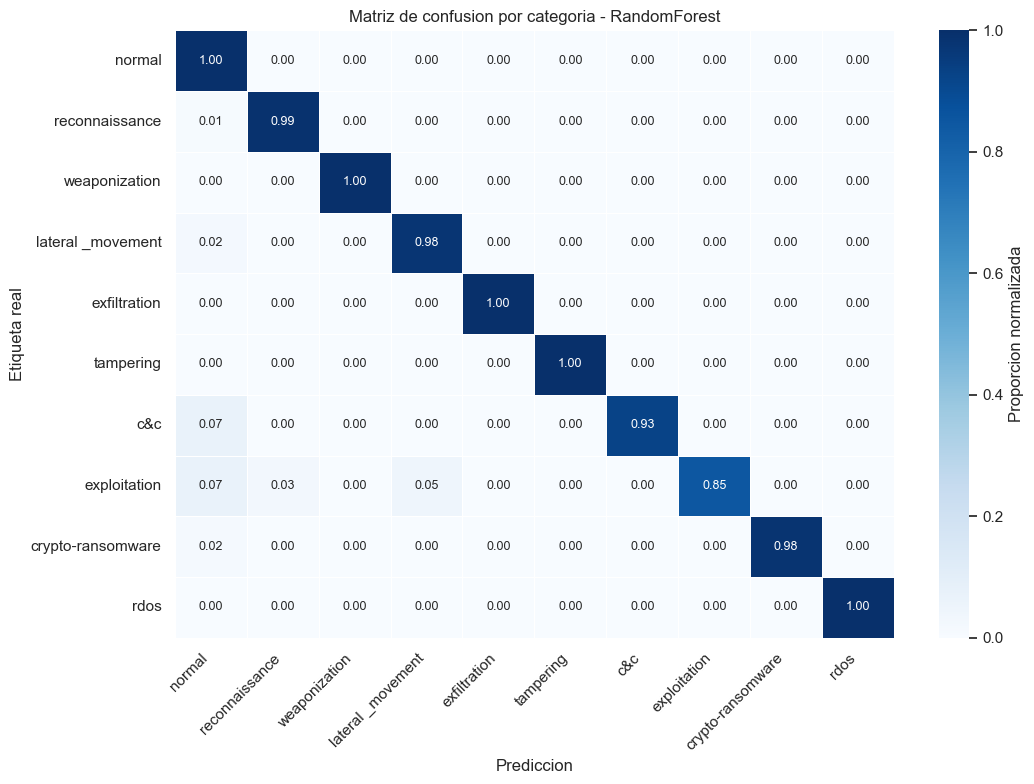

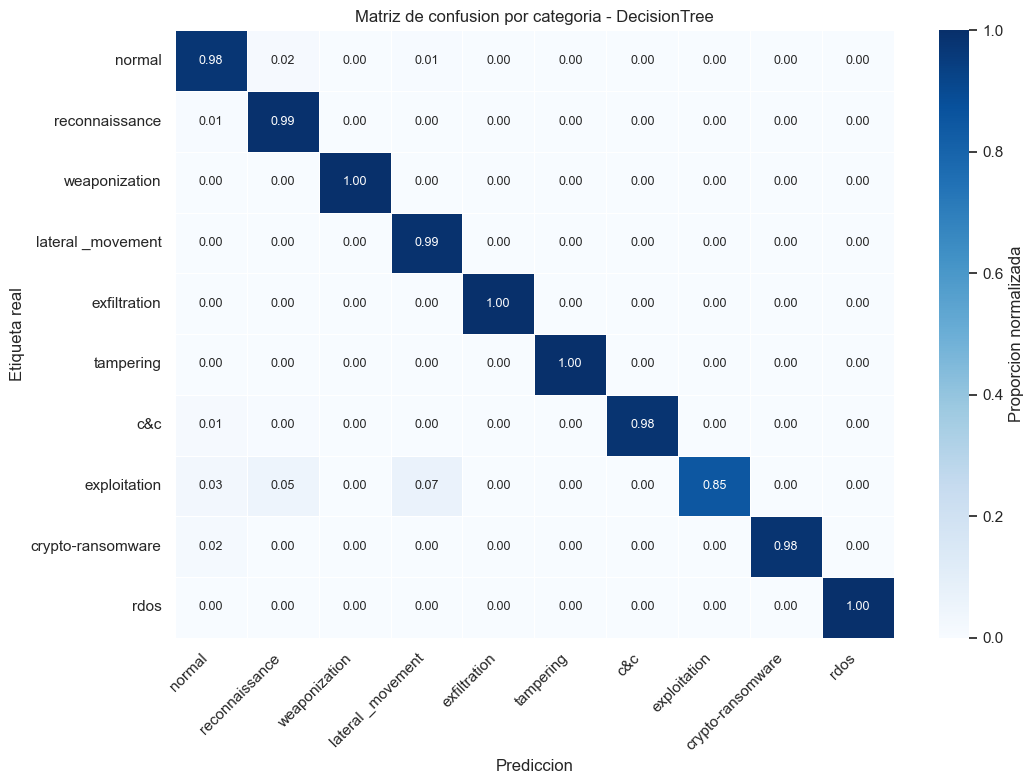

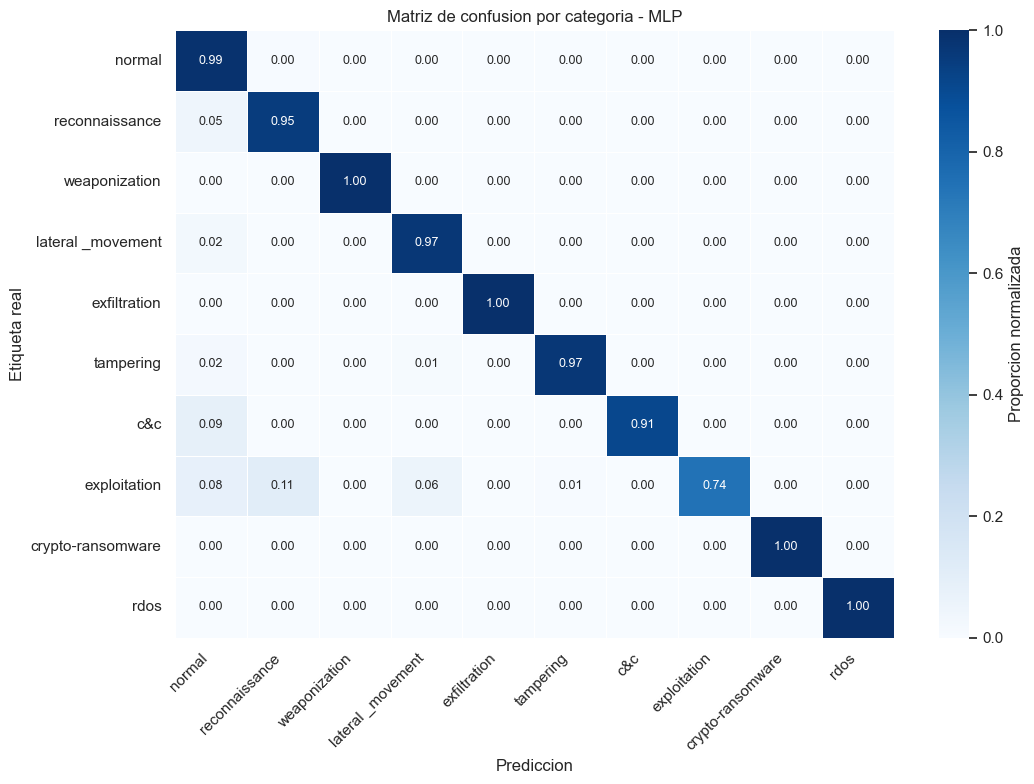

In [8]:
top_models = metrics_df['modelo'].head(3).tolist()
category_labels = ['normal', 'reconnaissance', 'weaponization', 'lateral _movement', 'exfiltration', 'tampering', 'c&c', 'exploitation', 'crypto-ransomware', 'rdos']

model_summary = metrics_df[metrics_df['modelo'].isin(top_models)][['modelo', 'test_f1_type', 'test_f1_cat', 'test_f1_bin', 'test_f1_mean']].copy()
display(model_summary)
model_summary.to_csv(TABLES_DIR / 'resumen_mejores_modelos.csv', index=False)


for model_name in top_models:
    pred_cat = test_predictions[model_name].map(type_to_category)
    cm = confusion_matrix(y_test_cat, pred_cat, labels=category_labels, normalize='true')
    cm_df = pd.DataFrame(cm, index=category_labels, columns=category_labels)
    cm_df.to_csv(TABLES_DIR / f'matriz_confusion_categoria_{model_name}.csv')

    plt.figure(figsize=(11, 8))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9},
        cbar_kws={'label': 'Proporcion normalizada'},
    )
    plt.title(f'Matriz de confusion por categoria - {model_name}')
    plt.xlabel('Prediccion')
    plt.ylabel('Etiqueta real')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'matriz_confusion_categoria_{model_name}.png', dpi=220, bbox_inches='tight')
    plt.show()


,support,recall_RandomForest,recall_DecisionTree,recall_MLP,mean_recall
fuzzing,204,0.6471,0.8382,0.3922,0.6258
mitm,19,0.6842,0.7895,0.6316,0.7018
tcp relay,352,0.7102,0.9489,0.6875,0.7822
reverse_shell,176,0.8693,0.8580,0.7557,0.8277
discovering_resources,3410,0.9689,0.9848,0.7821,0.9119
c&c,412,0.9296,0.9806,0.9126,0.9409
crypto-ransomware,54,0.9815,0.9815,1.0000,0.9877
normal,63213,0.9977,0.9755,0.9919,0.9884
false_data_injection,753,0.9987,0.9973,0.9708,0.9889
mqtt_cloud_broker_subscription,3489,0.9983,0.9903,0.9920,0.9935


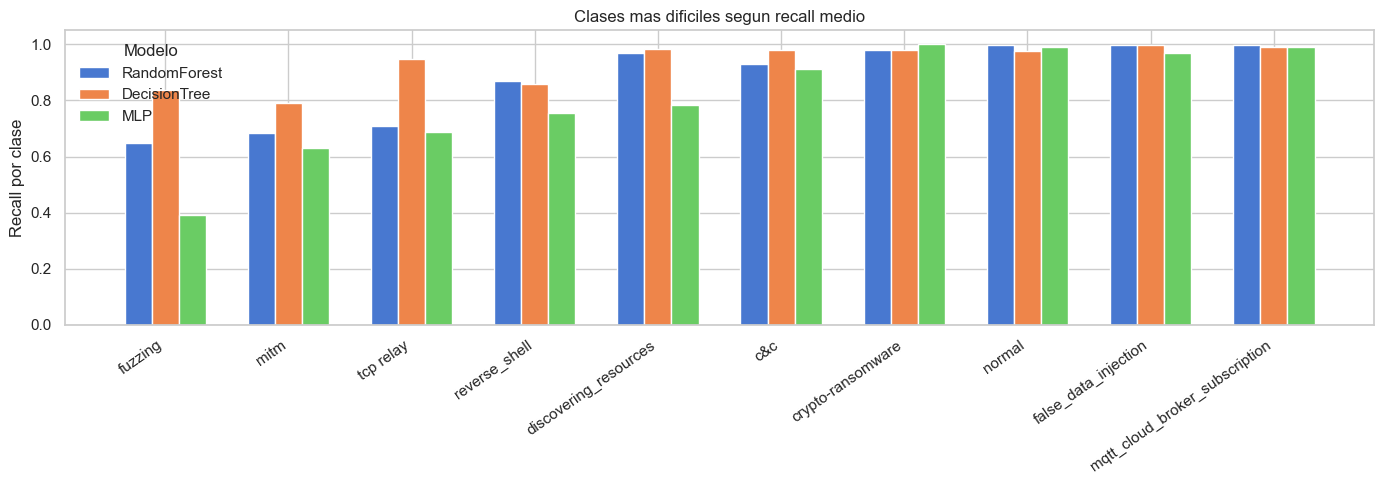

In [9]:
selected_reports = {model_name: reports_test[model_name] for model_name in top_models}
classes = [
    label
    for label in selected_reports[top_models[0]].index
    if label not in {'accuracy', 'macro avg', 'weighted avg'}
]

hard_classes = pd.DataFrame(
    {'support': selected_reports[top_models[0]].loc[classes, 'support'].astype(int)}
)
for model_name in top_models:
    hard_classes[f'recall_{model_name}'] = selected_reports[model_name].loc[classes, 'recall']

hard_classes['mean_recall'] = hard_classes[[col for col in hard_classes.columns if col.startswith('recall_')]].mean(axis=1)
hard_classes = hard_classes.sort_values(['mean_recall', 'support']).head(10)
display(hard_classes)

hard_classes.to_csv(TABLES_DIR / 'clases_mas_dificiles.csv')

plot_df = hard_classes.reset_index().rename(columns={'index': 'clase'})
recall_cols = [col for col in plot_df.columns if col.startswith('recall_')]

x = np.arange(len(plot_df))
width = 0.22
fig, ax = plt.subplots(figsize=(14, 5))
for idx, col in enumerate(recall_cols):
    ax.bar(x + idx * width - width, plot_df[col], width=width, label=col.replace('recall_', ''))

ax.set_xticks(x)
ax.set_xticklabels(plot_df['clase'], rotation=35, ha='right')
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Recall por clase')
ax.set_title('Clases mas dificiles segun recall medio')
ax.legend(title='Modelo')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clases_dificiles_recall.png', dpi=220, bbox_inches='tight')
plt.show()


### 8. Conclusiones del modelado <a name="8"></a>

Las conclusiones finales se calculan a partir de los resultados reales entrenados en este notebook. La lectura principal que esperamos contrastar es si los modelos basados en arboles siguen siendo los mas solidos para datos tabulares industriales, incluso cuando el objetivo pasa a ser la clasificación directa del tipo de trafico.


Tras entrenar los modelos directamente sobre `class1`, se observa que **RandomForest** obtiene el mejor rendimiento global en test, con una media simple de F1 de **0.9769**. El segundo modelo con mejor comportamiento global es **DecisionTree**, lo que refuerza la idea de que las familias basadas en arboles son especialmente adecuadas para este problema tabular.

A nivel de salida final por tipo (`class1`), el mejor F1 macro alcanza **0.9559**, mientras que la clasificacion por categoria y la binaria presentan valores todavia mas altos. Esto confirma que la dificultad principal no reside en separar `normal` frente a `attack`, sino en discriminar entre tipos de ataque con bajo soporte y patrones parcialmente solapados.

El modelo mas debil de la comparativa es **LogisticRegression**, lo que sirve como referencia de baseline. La red neuronal multicapa queda incorporada en el estudio como familia neuronal real entrenada dentro del notebook, permitiendo comparar aprendizaje automatico clasico frente a una alternativa neuronal sin recurrir a predicciones heredadas.

Las clases mas dificiles segun recall medio son: **fuzzing, mitm, tcp relay, reverse_shell y discovering_resources**. Este comportamiento es coherente con el fuerte desbalanceo observado ya en el Hito 2.